In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn import datasets
from sklearn import tree
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import LinearSegmentedColormap
import sklearn
from sklearn.utils import Bunch

In [2]:
# Q1: Load HW6.csv file
data = pd.read_csv("HW6.csv")

In [3]:
# Label encode categorical features
le = preprocessing.LabelEncoder()
for i in range(data.shape[1]):
    if data.dtypes[i] == "object":
        data.iloc[:, i] = le.fit_transform(data.iloc[:, i])

# Create dataBunch
dataBunch = Bunch(
    data=data.iloc[:, 0:5],
    target=data.iloc[:, 5],
    feature_names=np.array(data.columns[:5]),
    target_names=np.unique(data["target"]),
)

# Select features and labels
X = np.array(dataBunch.data.iloc[:, 0:2])
y = np.array(dataBunch.target).ravel()

# Define estimators
estimators = [
    ("k=9", KMeans(n_clusters=9)),
    ("k=6", KMeans(n_clusters=6)),
    ("k=3", KMeans(n_clusters=3)),
    ("k=3(random initialization)", KMeans(n_clusters=3, n_init=1, init="random")),
]

/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_15785/3569834862.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data.dtypes[i] == "object":
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_15785/3569834862.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data.dtypes[i] == "object":
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_15785/3569834862.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.ilo

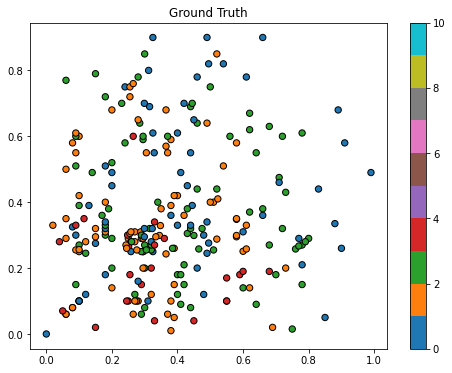

In [ ]:
plt.figure(figsize=(8, 6))

# Q2: scatterplot attribute 0 and 1 as x,y and color as y.transpose()
sc = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y.transpose(),
    cmap="tab10",
    edgecolors="k",
    s=40,
    vmin=0,
    vmax=10,
)
plt.colorbar(sc)
plt.title("Ground Truth")
plt.show()

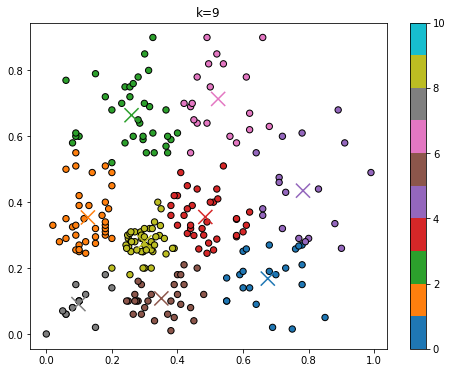

Accuracy score for k=9: 0.11284046692607004


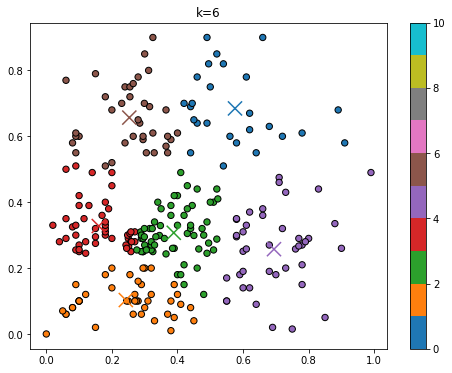

Accuracy score for k=6: 0.2140077821011673


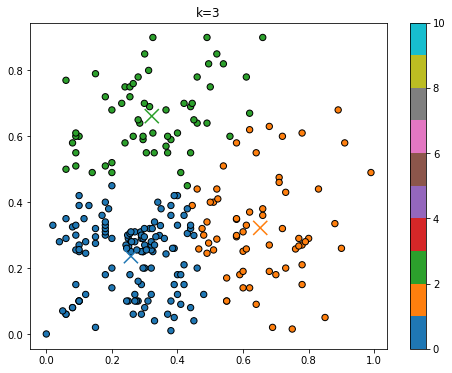

Accuracy score for k=3: 0.245136186770428


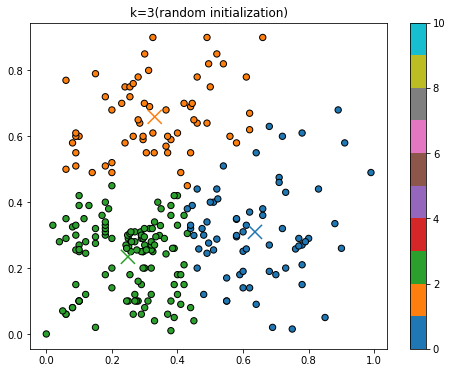

Accuracy score for k=3(random initialization): 0.29571984435797666


In [ ]:
for name, model in estimators:
    plt.figure(figsize=(8, 6))
    # Q3: fit the model on X
    model.fit(X)
    labels = model.labels_

    # let the color of the points related with the labels
    # define vmin and vmax for the upper and lower limits of the colorbar, such that all plots will have the same color scale,
    # tab-10 is the colormap for discrete value

    # Q4: scatterplot attribute 0 and 1 as x,y and color as "labels" variable
    sc = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap="tab10",
        edgecolors="k",
        s=40,
        vmin=0,
        vmax=10,
    )
    plt.colorbar(sc)  # show colorbar

    # cluster_centers_ is an array, [row = n_clusters, col = n_features],
    # the cluster centers are marked by 'x'

    # Q5: scatterplot centroids
    plt.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        marker="x",
        s=200,
        c=np.arange(len(model.cluster_centers_)),
        cmap="tab10",
        vmin=0,
        vmax=10,
    )
    plt.title(name)
    plt.show()

    y = np.asarray(y, dtype=np.int64)
    labels = np.asarray(labels, dtype=np.int64)

    # print("y   dtype:", y.dtype,      "shape:", y.shape,      "unique:", np.unique(y))
    # print("pred dtype:", labels.dtype, "shape:", labels.shape, "unique:", np.unique(labels))
    # Q6: print accuracy score
    print(f"Accuracy score for {name}: {accuracy_score(y, labels)}")